In [1]:
# (No installation required)

In [2]:
# Import required libraries for sentiment analysis with open-source LLMs
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import time
import datetime
from tqdm import tqdm
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report,
    matthews_corrcoef,
)

print("✓ Setup complete for open-source LLM sentiment analysis")

✓ Setup complete for open-source LLM sentiment analysis


## 1. Load Dataset

Load the FinancialPhraseBank dataset for sentiment analysis.

In [3]:
# Load the 100% agreement dataset (highest quality)
data_path = "../../../Startified Data PMP/Processed Data/processed_data.csv"

df = pd.read_csv(data_path)
df.rename(columns={"sentiment": "true_sentiment"}, inplace=True)
df.rename(columns={"sentences": "sentence"}, inplace=True)

print(f"Dataset loaded: {len(df)} sentences")

# Display sample
print("\n" + "=" * 80)
print("Sample sentences:")
print("=" * 80)
display(df.sample(5, random_state=42))

Dataset loaded: 210 sentences

Sample sentences:


,sentence,true_sentiment,word_count,char_length
30,Tallink Silja attributes the significant drop ...,negative,46,267
172,"ADP News - Feb 13 , 2009 - Finnish retailer Ke...",negative,43,207
84,20 October 2010 - Finnish environmental manage...,negative,43,237
199,"Finnair 's Tallinn-based subsidiary , Aero AS ...",negative,31,178
60,MegaFon 's subscriber base increased 16.1 % in...,positive,50,246


## 2. Few-Shot Examples

Curated examples (2 positive, 2 negative, 1 neutral) representing typical financial sentiment patterns.

In [4]:
# Curated few-shot examples - BALANCED with emphasis on negative detection
FEW_SHOT_EXAMPLES = [
    {
        "sentence": "Operating profit rose to EUR 13.1 mn from EUR 8.7 mn in the corresponding period in 2007.",
        "sentiment": "positive",
        "rationale": "Operating profit increased significantly, indicating improved financial performance.",
    },
    {
        "sentence": "Net sales increased by 18.5% to EUR 167.8 million compared to the previous year.",
        "sentiment": "positive",
        "rationale": "Strong revenue growth of 18.5% signals business expansion and market success.",
    },
    {
        "sentence": "The company reported a net loss of EUR 2.5 million compared to a profit of EUR 1.2 million in the previous quarter.",
        "sentiment": "negative",
        "rationale": "Shift from profit to loss represents deteriorating financial health.",
    },
    {
        "sentence": "Sales decreased by 15% year-over-year due to weakening demand in key markets.",
        "sentiment": "negative",
        "rationale": "Significant sales decline indicates business challenges and market difficulties.",
    },
    {
        "sentence": "Operating loss widened to EUR 5.8 million from EUR 3.2 million in the same period last year.",
        "sentiment": "negative",
        "rationale": "Widening losses show worsening profitability and deteriorating business conditions.",
    },
    {
        "sentence": "The company announced the appointment of a new chief financial officer effective next month.",
        "sentiment": "neutral",
        "rationale": "Executive appointment is routine corporate news without clear financial impact.",
    },
]

print("Few-Shot Examples:")

print("=" * 80)


for i, ex in enumerate(FEW_SHOT_EXAMPLES, 1):
    print(f"Rationale: {ex['rationale']}")
    print(f"Sentence: {ex['sentence']}")
    print(f"\nExample {i} [{ex['sentiment'].upper()}]:")

Few-Shot Examples:
Rationale: Operating profit increased significantly, indicating improved financial performance.
Sentence: Operating profit rose to EUR 13.1 mn from EUR 8.7 mn in the corresponding period in 2007.

Example 1 [POSITIVE]:
Rationale: Strong revenue growth of 18.5% signals business expansion and market success.
Sentence: Net sales increased by 18.5% to EUR 167.8 million compared to the previous year.

Example 2 [POSITIVE]:
Rationale: Shift from profit to loss represents deteriorating financial health.
Sentence: The company reported a net loss of EUR 2.5 million compared to a profit of EUR 1.2 million in the previous quarter.

Example 3 [NEGATIVE]:
Rationale: Significant sales decline indicates business challenges and market difficulties.
Sentence: Sales decreased by 15% year-over-year due to weakening demand in key markets.

Example 4 [NEGATIVE]:
Rationale: Widening losses show worsening profitability and deteriorating business conditions.
Sentence: Operating loss widened

## 3. Few-Shot Prompt Design

Prompt template for open-source LLMs using few-shot examples.

In [5]:
def create_few_shot_prompt(sentence):
    """
    Creates a few-shot prompt with 6 labeled examples (balanced representation).
    """
    examples_text = ""
    for i, ex in enumerate(FEW_SHOT_EXAMPLES, 1):
        examples_text += f"""\nExample {i}:
Sentence: "{ex["sentence"]}"
Analysis:
{{
    "sentiment": "{ex["sentiment"]}",
    "confidence": 0.95,
    "rationale": "{ex["rationale"]}"
}}
"""

    prompt = f"""You are a financial sentiment analysis expert. Analyze financial statements with precision.

Classify the sentiment as "positive", "negative", or "neutral" from an investor's perspective.

Guidelines:
- Positive: Financial improvements, growth, profits, revenue increases, cost reductions, successful expansions
- Negative: Financial declines, losses, revenue drops, cost increases, widening losses, failed ventures, layoffs
- Neutral: Factual statements with no clear financial impact, routine announcements, balanced mixed signals

⚠️ IMPORTANT: Pay special attention to negative indicators (losses, declines, decreases, deterioration).

Here are {len(FEW_SHOT_EXAMPLES)} examples to learn from:
{examples_text}

Now classify this new statement:
Sentence: "{sentence}"

Return ONLY valid JSON in this exact format:
{{
    "sentiment": "positive/negative/neutral",
    "confidence": 0.0-1.0,
    "rationale": "Brief explanation"
}}
"""
    return prompt


# Test prompt
print("=" * 80)
print("FEW-SHOT PROMPT EXAMPLE")

print("=" * 80)
print(create_few_shot_prompt(df["sentence"].iloc[0]))

FEW-SHOT PROMPT EXAMPLE
You are a financial sentiment analysis expert. Analyze financial statements with precision.

Classify the sentiment as "positive", "negative", or "neutral" from an investor's perspective.

Guidelines:
- Positive: Financial improvements, growth, profits, revenue increases, cost reductions, successful expansions
- Negative: Financial declines, losses, revenue drops, cost increases, widening losses, failed ventures, layoffs
- Neutral: Factual statements with no clear financial impact, routine announcements, balanced mixed signals

⚠️ IMPORTANT: Pay special attention to negative indicators (losses, declines, decreases, deterioration).

Here are 6 examples to learn from:

Example 1:
Sentence: "Operating profit rose to EUR 13.1 mn from EUR 8.7 mn in the corresponding period in 2007."
Analysis:
{
    "sentiment": "positive",
    "confidence": 0.95,
    "rationale": "Operating profit increased significantly, indicating improved financial performance."
}

Example 2:
Sent

## 4. Model Inference Functions

Functions for calling open-source LLMs (Groq API) and parsing their responses.

In [6]:
# Call Ollama models locally via Ollama API for Llama, Qwen, Deepseek
def call_ollama(prompt, model_name, temperature=0.0):
    """
    Call Ollama models locally via Ollama API for Llama, Qwen, Deepseek.
    """
    url = "http://localhost:11434/api/generate"
    payload = {
        "model": model_name,
        "prompt": prompt,
        "options": {"temperature": temperature},
        "stream": False
    }
    try:
        import requests
        response = requests.post(url, json=payload)
        response.raise_for_status()
        result = response.json()
        return result.get("response", None)
    except Exception as e:
        print(f"Ollama error: {str(e)[:100]}")
        return None

def parse_response(response_text):
    """Parse JSON response from model"""
    try:
        # Try to extract JSON from response
        if "```json" in response_text:
            json_str = response_text.split("```json")[1].split("```")[0].strip()
        elif "```" in response_text:
            json_str = response_text.split("```")[1].strip()
        else:
            json_str = response_text.strip()
        result = json.loads(json_str)
        return result
    except Exception as e:
        print("Parse error: {}".format(str(e)[:100]))
        print("Raw response was:\n{}".format(response_text))
        # Fallback: try to extract sentiment with regex
        response_lower = response_text.lower() if response_text else ""
        if "positive" in response_lower and "negative" not in response_lower:
            return {
                "sentiment": "positive",
                "confidence": 0.5,
                "rationale": "Parsed from text",
            }
        elif "negative" in response_lower:
            return {
                "sentiment": "negative",
                "confidence": 0.5,
                "rationale": "Parsed from text",
            }
        elif "neutral" in response_lower:
            return {
                "sentiment": "neutral",
                "confidence": 0.5,
                "rationale": "Parsed from text",
            }
        return None

print("✓ Model inference functions defined (llama3.1:8b, qwen3:8b, deepseek-r1:8b)")

✓ Model inference functions defined (llama3.1:8b, qwen3:8b, deepseek-r1:8b)


In [7]:
# Test API calls with a sample sentence
test_sentence = df["sentence"].iloc[0]
test_prompt = create_few_shot_prompt(test_sentence)

print("=" * 80)
print("Testing llama3.1:8b...")
print("=" * 80)
llama3_response = call_ollama(test_prompt, model_name="llama3.1:8b")
if llama3_response:
    print(f"✓ Response received (length: {len(llama3_response)})")
    print(f"Response: {llama3_response[:500]}")
    try:
        parsed = json.loads(llama3_response)
        print(f"✓ Parsed successfully: {parsed}")
    except Exception as e:
        print(f"✗ Failed to parse response as JSON: {e}")
else:
    print("✗ llama3.1:8b call failed - no response received")

Testing llama3.1:8b...
✓ Response received (length: 210)
Response: {
    "sentiment": "neutral",
    "confidence": 0.95,
    "rationale": "The statement lists supported Nokia phones, which is a factual and routine announcement without clear financial impact or implications."
}
✓ Parsed successfully: {'sentiment': 'neutral', 'confidence': 0.95, 'rationale': 'The statement lists supported Nokia phones, which is a factual and routine announcement without clear financial impact or implications.'}


In [8]:
print("\n" + "=" * 80)
print("Testing qwen3:8b...")
print("=" * 80)
qwen3_response = call_ollama(test_prompt, model_name="qwen3:8b")
if qwen3_response:
    print(f"✓ Response received (length: {len(qwen3_response)})")
    print(f"Response: {qwen3_response[:500]}")
    parsed = parse_response(qwen3_response)
    if parsed:
        print(f"✓ Parsed successfully: {parsed}")
    else:
        print("✗ Failed to parse response")
else:
    print("✗ qwen3:8b call failed - no response received")


Testing qwen3:8b...
✓ Response received (length: 166)
Response: {
    "sentiment": "neutral",
    "confidence": 0.95,
    "rationale": "Factual list of supported devices without financial implications or performance indicators."
}
✓ Parsed successfully: {'sentiment': 'neutral', 'confidence': 0.95, 'rationale': 'Factual list of supported devices without financial implications or performance indicators.'}


In [9]:
print("\n" + "=" * 80)
print("Testing deepseek-r1:8b...")
print("=" * 80)
deepseek_response = call_ollama(test_prompt, model_name="deepseek-r1:8b")
if deepseek_response:
    print(f"✓ Response received (length: {len(deepseek_response)})")
    print(f"Response: {deepseek_response[:500]}")
    parsed = parse_response(deepseek_response)
    if parsed:
        print(f"✓ Parsed successfully: {parsed}")
    else:
        print("✗ Failed to parse response")
else:
    print("✗ deepseek-r1:8b call failed - no response received")


Testing deepseek-r1:8b...
✓ Response received (length: 213)
Response: {
    "sentiment": "neutral",
    "confidence": 0.95,
    "rationale": "The sentence provides a factual list of supported Nokia phone models without any financial metrics or indicators of financial performance."
}
✓ Parsed successfully: {'sentiment': 'neutral', 'confidence': 0.95, 'rationale': 'The sentence provides a factual list of supported Nokia phone models without any financial metrics or indicators of financial performance.'}


## 5. Run Experiments

Run few-shot sentiment analysis using the same open-source LLMs as in E1, E2, E3 (Zero-Shot):
- **E4:** Llama3.1:8b (Few-Shot)
- **E5:** Qwen3:8b (Few-Shot)
- **E6:** Deepseek-r1:8b (Few-Shot)

All models are called via Ollama API for consistency with the zero-shot experiments.

### E4: ollama/llama3.1:8b (Few-Shot)

Using the same Llama3.1:8b model as in E1, but with few-shot prompt.

In [11]:
# E4: llama3.1:8b (Few-Shot)
print("Running E4: llama3.1:8b (Few-Shot)...")
E4_results = []

for idx, row in tqdm(df.iterrows(), total=len(df), desc="E4 Progress"):
    prompt = create_few_shot_prompt(row["sentence"])
    response = call_ollama(prompt, model_name="llama3.1:8b")

    if response:
        parsed = parse_response(response)
        if parsed:
            E4_results.append(
                {
                    "sentence": row["sentence"],
                    "true_sentiment": row["true_sentiment"],
                    "predicted_sentiment": parsed.get("sentiment", "unknown"),
                    "confidence": parsed.get("confidence", 0),
                    "rationale": parsed.get("rationale", ""),
                }
            )
        else:
            E4_results.append(
                {
                    "sentence": row["sentence"],
                    "true_sentiment": row["true_sentiment"],
                    "predicted_sentiment": "error",
                    "confidence": 0,
                    "rationale": "Parse error",
                }
            )

    time.sleep(0.5)  # Rate limiting

e4_df = pd.DataFrame(E4_results)
print(f"\n✓ E4 completed: {len(e4_df)} predictions")
display(e4_df.head())

Running E4: llama3.1:8b (Few-Shot)...


E4 Progress: 100%|██████████| 210/210 [16:49<00:00,  4.80s/it]


✓ E4 completed: 210 predictions


,sentence,true_sentiment,predicted_sentiment,confidence,rationale
0,"Supported Nokia phones include : N96 , N95-8GB...",neutral,neutral,0.95,"The statement lists supported Nokia phones, wh..."
1,Our customers come from the following countrie...,neutral,neutral,0.95,The statement lists countries where the compan...
2,"Target company : Tieto Corporation , Business ...",neutral,neutral,0.95,The statement appears to be a factual announce...
3,Cablevision Systems Corp. CVC Their Madison Sq...,neutral,neutral,0.95,The statement provides factual information abo...
4,Panostaja Oyj 's Board also decided at its org...,neutral,neutral,0.95,The statement is a routine corporate announcem...


In [13]:
print("True vs Predicted Sentiment:")
print(e4_df["true_sentiment"].value_counts())
print(e4_df["predicted_sentiment"].value_counts())

True vs Predicted Sentiment:
true_sentiment
neutral     70
negative    70
positive    70
Name: count, dtype: int64
predicted_sentiment
negative    76
neutral     69
positive    65
Name: count, dtype: int64


### E5: ollama/qwen3:8b (Few-Shot)

Using the same Qwen3:8b model as in E2, but with few-shot prompt.

In [14]:
# E5: qwen3:8b (Few-Shot)
print("Running E5: qwen3:8b (Few-Shot)...")
E5_results = []

for idx, row in tqdm(df.iterrows(), total=len(df),  desc="E5 Progress"):
    prompt = create_few_shot_prompt(row["sentence"])
    response = call_ollama(prompt, model_name="qwen3:8b")

    if response:
        parsed = parse_response(response)
        if parsed:
            E5_results.append(
                {
                    "sentence": row["sentence"],
                    "true_sentiment": row["true_sentiment"],
                    "predicted_sentiment": parsed.get("sentiment", "unknown"),
                    "confidence": parsed.get("confidence", 0),
                    "rationale": parsed.get("rationale", ""),
                }
            )
        else:
            E5_results.append(
                {
                    "sentence": row["sentence"],
                    "true_sentiment": row["true_sentiment"],
                    "predicted_sentiment": "error",
                    "confidence": 0,
                    "rationale": "Parse error",
                }
            )

    time.sleep(0.5)

e5_df = pd.DataFrame(E5_results)
print(f"\n✓ E5 completed: {len(e5_df)} predictions")
display(e5_df.head())

Running E5: qwen3:8b (Few-Shot)...


E5 Progress: 100%|██████████| 210/210 [1:18:28<00:00, 22.42s/it]


✓ E5 completed: 210 predictions


,sentence,true_sentiment,predicted_sentiment,confidence,rationale
0,"Supported Nokia phones include : N96 , N95-8GB...",neutral,neutral,0.95,Factual list of supported devices without fina...
1,Our customers come from the following countrie...,neutral,neutral,0.95,Factual statement about customer geographic di...
2,"Target company : Tieto Corporation , Business ...",neutral,neutral,0.95,Factual statement about shareholding details w...
3,Cablevision Systems Corp. CVC Their Madison Sq...,neutral,neutral,0.95,Describes asset ownership and business diversi...
4,Panostaja Oyj 's Board also decided at its org...,neutral,neutral,0.95,Describes a procedural corporate action with n...


In [15]:
print("True vs Predicted Sentiment:")
print(e5_df["true_sentiment"].value_counts())
print(e5_df["predicted_sentiment"].value_counts())

True vs Predicted Sentiment:
true_sentiment
neutral     70
negative    70
positive    70
Name: count, dtype: int64
predicted_sentiment
neutral     80
negative    66
positive    64
Name: count, dtype: int64


### E6: ollama/deepseek-r1:8b (Few-Shot)

Using the same Deepseek-r1:8b model as in E3, but with few-shot prompt.

In [16]:
# E6: deepseek-r1:8b (Few-Shot)
print("Running E6: deepseek-r1:8b (Few-Shot)...")
E6_results = []

for idx, row in tqdm(df.iterrows(), total=len(df), desc="E6 Progress"):
    prompt = create_few_shot_prompt(row["sentence"])
    response = call_ollama(prompt, model_name="deepseek-r1:8b")

    if response:
        parsed = parse_response(response)
        if parsed:
            E6_results.append(
                {
                    "sentence": row["sentence"],
                    "true_sentiment": row["true_sentiment"],
                    "predicted_sentiment": parsed.get("sentiment", "unknown"),
                    "confidence": parsed.get("confidence", 0),
                    "rationale": parsed.get("rationale", ""),
                }
            )
        else:
            E6_results.append(
                {
                    "sentence": row["sentence"],
                    "true_sentiment": row["true_sentiment"],
                    "predicted_sentiment": "error",
                    "confidence": 0,
                    "rationale": "Parse error",
                }
            )
    else:
        E6_results.append(
            {
                "sentence": row["sentence"],
                "true_sentiment": row["true_sentiment"],
                "predicted_sentiment": "error",
                "confidence": 0,
                "rationale": "Model error",
            }
        )

e6_df = pd.DataFrame(E6_results)
print(f"\n✓ E6 completed: {len(e6_df)} predictions")
display(e6_df.head())

Running E6: deepseek-r1:8b (Few-Shot)...


E6 Progress: 100%|██████████| 210/210 [1:26:53<00:00, 24.83s/it]


✓ E6 completed: 210 predictions


,sentence,true_sentiment,predicted_sentiment,confidence,rationale
0,"Supported Nokia phones include : N96 , N95-8GB...",neutral,neutral,0.95,The sentence provides a factual list of suppor...
1,Our customers come from the following countrie...,neutral,neutral,0.95,The statement provides factual information abo...
2,"Target company : Tieto Corporation , Business ...",neutral,neutral,0.95,Factual announcement of a corporate holding ch...
3,Cablevision Systems Corp. CVC Their Madison Sq...,neutral,neutral,0.95,The statement describes ownership of sports te...
4,Panostaja Oyj 's Board also decided at its org...,neutral,neutral,0.95,The statement describes a routine implementati...


In [17]:
print("True vs Predicted Sentiment:")
print(e6_df["true_sentiment"].value_counts())
print(e6_df["predicted_sentiment"].value_counts())

True vs Predicted Sentiment:
true_sentiment
neutral     70
negative    70
positive    70
Name: count, dtype: int64
predicted_sentiment
neutral     71
positive    70
negative    69
Name: count, dtype: int64


## 6. Calculate Metrics

Compute accuracy, F1, precision, recall, and confusion matrices for each model.

In [18]:
def calculate_metrics(df, exp_name):
    """Calculate all evaluation metrics"""
    # Check if dataframe is empty or missing required columns
    if df.empty or "predicted_sentiment" not in df.columns:
        print(f"⚠️ Warning: {exp_name} has no valid predictions!")
        return (
            {
                "Experiment": exp_name,
                "Total Samples": 0,
                "Valid Predictions": 0,
                "Accuracy": 0,
                "Macro-F1": 0,
                "Weighted-F1": 0,
                "Macro-Precision": 0,
                "Macro-Recall": 0,
                "MCC": 0,
                "Positive_Precision": 0,
                "Positive_Recall": 0,
                "Positive_F1": 0,
                "Negative_Precision": 0,
                "Negative_Recall": 0,
                "Negative_F1": 0,
                "Neutral_Precision": 0,
                "Neutral_Recall": 0,
                "Neutral_F1": 0,
            },
            np.zeros((3, 3)),
            pd.DataFrame(),
        )

    # Filter out errors
    valid_df = df[
        df["predicted_sentiment"].isin(["positive", "negative", "neutral"])
    ].copy()

    # Check if we have valid predictions
    if valid_df.empty:
        print(f"⚠️ Warning: {exp_name} has no valid predictions after filtering!")
        return (
            {
                "Experiment": exp_name,
                "Total Samples": len(df),
                "Valid Predictions": 0,
                "Accuracy": 0,
                "Macro-F1": 0,
                "Weighted-F1": 0,
                "Macro-Precision": 0,
                "MCC": 0,
                "Positive_Precision": 0,
                "Positive_Recall": 0,
                "Positive_F1": 0,
                "Negative_Precision": 0,
                "Negative_Recall": 0,
                "Negative_F1": 0,
                "Neutral_Precision": 0,
                "Neutral_Recall": 0,
                "Neutral_F1": 0,
            },
            np.zeros((3, 3)),
            pd.DataFrame(),
        )

    y_true = valid_df["true_sentiment"]
    y_pred = valid_df["predicted_sentiment"]

    metrics = {
        "Experiment": exp_name,
        "Total Samples": len(df),
        "Valid Predictions": len(valid_df),
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro-F1": f1_score(y_true, y_pred, average="macro"),
        "Weighted-F1": f1_score(y_true, y_pred, average="weighted"),
        "Macro-Precision": precision_score(y_true, y_pred, average="macro"),
        "Macro-Recall": recall_score(y_true, y_pred, average="macro"),
    }

    # Per-class metrics
    labels = ["positive", "negative", "neutral"]
    precision_per_class = precision_score(
        y_true, y_pred, labels=labels, average=None, zero_division=0
    )
    recall_per_class = recall_score(
        y_true, y_pred, labels=labels, average=None, zero_division=0
    )
    f1_per_class = f1_score(
        y_true, y_pred, labels=labels, average=None, zero_division=0
    )

    for i, label in enumerate(labels):
        metrics[f"{label.capitalize()}_Precision"] = precision_per_class[i]
        metrics[f"{label.capitalize()}_Recall"] = recall_per_class[i]
        metrics[f"{label.capitalize()}_F1"] = f1_per_class[i]

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    return metrics, cm, valid_df


# Calculate metrics for all experiments
e4_metrics, e4_cm, e4_valid = calculate_metrics(e4_df, "E4: Llama-3.1:8b (Few-Shot)")
e5_metrics, e5_cm, e5_valid = calculate_metrics(e5_df, "E5: Qwen3:8b (Few-Shot)")
e6_metrics, e6_cm, e6_valid = calculate_metrics(e6_df, "E6: Deepseek-r1:8b (Few-Shot)")

# Create metrics comparison table
metrics_df = pd.DataFrame([e4_metrics, e5_metrics, e6_metrics])

print("\n" + "=" * 80)
print("FEW-SHOT PERFORMANCE COMPARISON")
print("=" * 80)
display(
    metrics_df[
        ["Experiment", "Accuracy", "Macro-F1", "Macro-Precision", "Macro-Recall"]
    ].round(4)
)


FEW-SHOT PERFORMANCE COMPARISON


,Experiment,Accuracy,Macro-F1,Macro-Precision,Macro-Recall
0,E4: Llama-3.1:8b (Few-Shot),0.9571,0.9570,0.9589,0.9571
1,E5: Qwen3:8b (Few-Shot),0.9524,0.9530,0.9583,0.9524
2,E6: Deepseek-r1:8b (Few-Shot),0.9381,0.9382,0.9384,0.9381


## 7. Visualize Results

Visualize performance metrics and confusion matrices for all open-source LLMs.

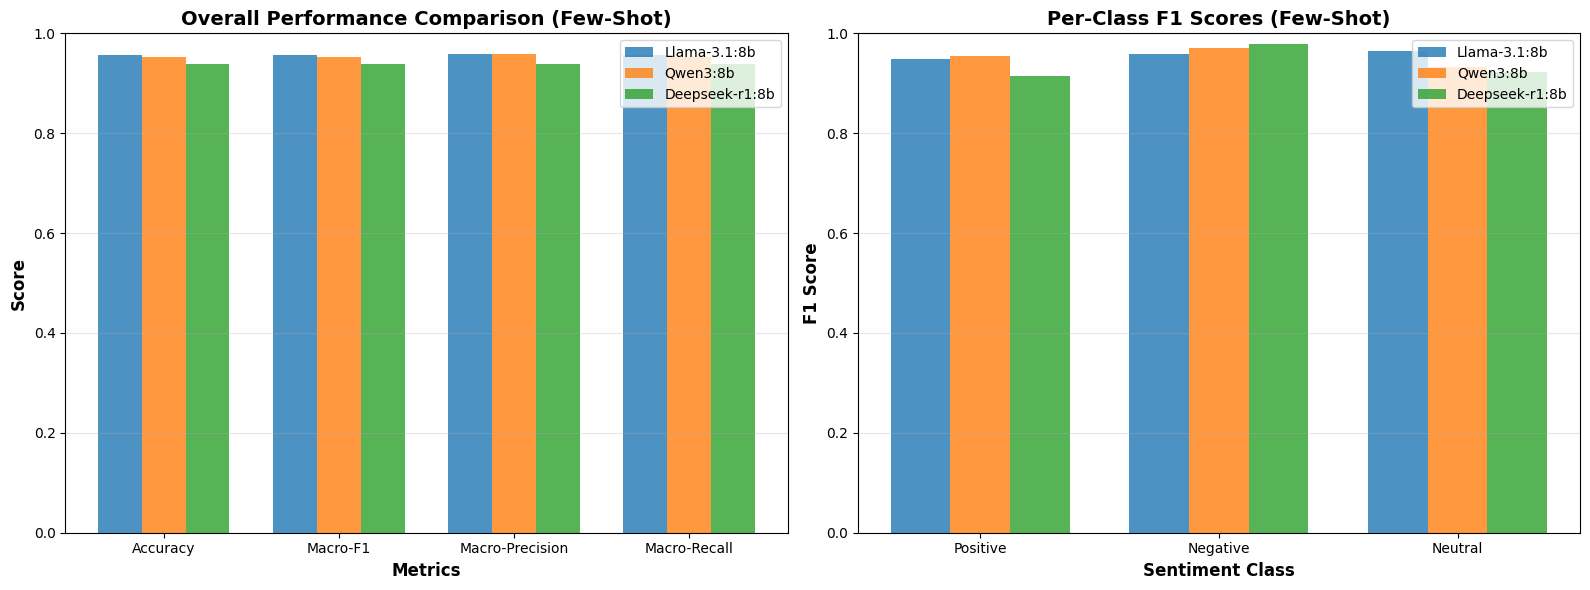

In [19]:
# Performance comparison bar chart
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Overall metrics
metrics_to_plot = ["Accuracy", "Macro-F1", "Macro-Precision", "Macro-Recall"]
x = np.arange(len(metrics_to_plot))
width = 0.25

for i, (metrics, label) in enumerate(
    [
        (e4_metrics, "Llama-3.1:8b"),
        (e5_metrics, "Qwen3:8b"),
        (e6_metrics, "Deepseek-r1:8b"),
    ]
):
    values = [metrics[m] for m in metrics_to_plot]
    axes[0].bar(x + i * width, values, width, label=label, alpha=0.8)

axes[0].set_xlabel("Metrics", fontsize=12, weight="bold")
axes[0].set_ylabel("Score", fontsize=12, weight="bold")
axes[0].set_title(
    "Overall Performance Comparison (Few-Shot)", fontsize=14, weight="bold"
)
axes[0].set_xticks(x + width)
axes[0].set_xticklabels(metrics_to_plot)
axes[0].legend()
axes[0].set_ylim([0, 1])
axes[0].grid(axis="y", alpha=0.3)

# Per-class F1 scores
classes = ["Positive", "Negative", "Neutral"]
x2 = np.arange(len(classes))

for i, (metrics, label) in enumerate(
    [
        (e4_metrics, "Llama-3.1:8b"),
        (e5_metrics, "Qwen3:8b"),
        (e6_metrics, "Deepseek-r1:8b"),
    ]
):
    values = [metrics[f"{c}_F1"] for c in classes]
    axes[1].bar(x2 + i * width, values, width, label=label, alpha=0.8)

axes[1].set_xlabel("Sentiment Class", fontsize=12, weight="bold")
axes[1].set_ylabel("F1 Score", fontsize=12, weight="bold")
axes[1].set_title("Per-Class F1 Scores (Few-Shot)", fontsize=14, weight="bold")
axes[1].set_xticks(x2 + width)
axes[1].set_xticklabels(classes)
axes[1].legend()
axes[1].set_ylim([0, 1])
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("few_shot_performance_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

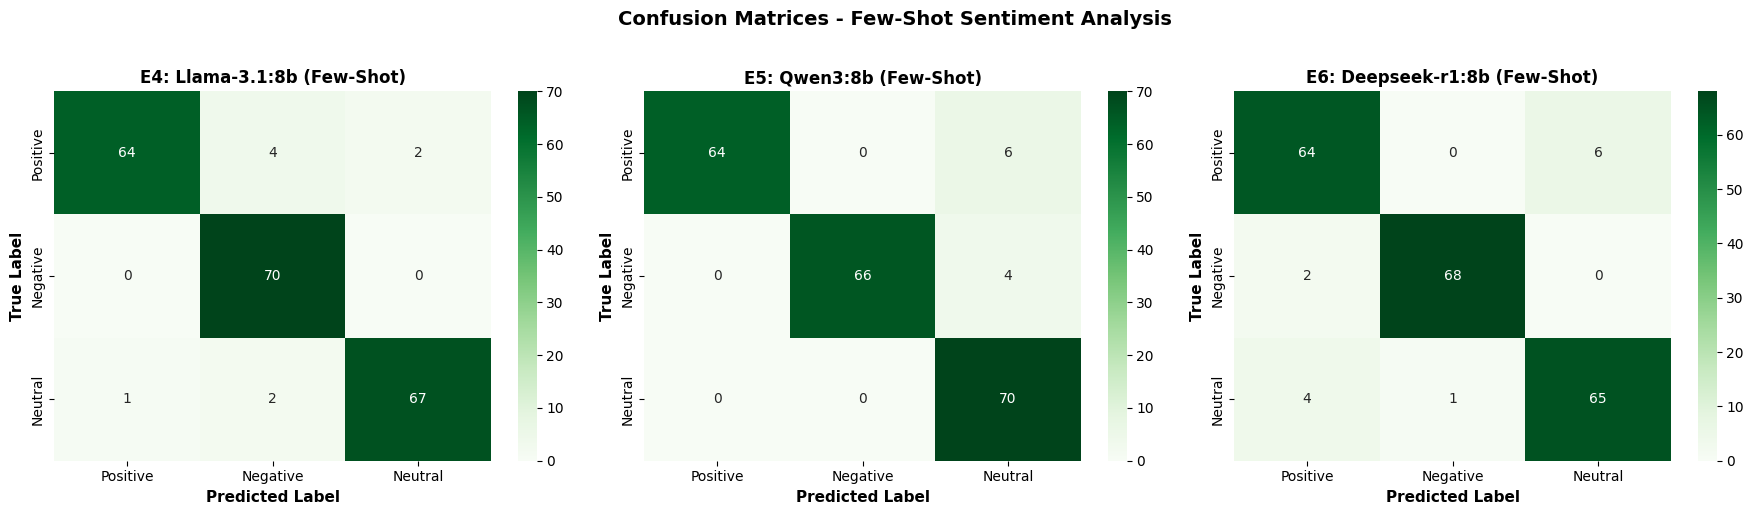

In [20]:
# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
labels = ["Positive", "Negative", "Neutral"]

for idx, (cm, title) in enumerate(
    [
        (e4_cm, "E4: Llama-3.1:8b (Few-Shot)"),
        (e5_cm, "E5: Qwen3:8b (Few-Shot)"),
        (e6_cm, "E6: Deepseek-r1:8b (Few-Shot)"),
    ]
):
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Greens",
        xticklabels=labels,
        yticklabels=labels,
        ax=axes[idx],
    )
    axes[idx].set_title(title, fontsize=12, weight="bold")
    axes[idx].set_ylabel("True Label", fontsize=11, weight="bold")
    axes[idx].set_xlabel("Predicted Label", fontsize=11, weight="bold")

plt.suptitle(
    "Confusion Matrices - Few-Shot Sentiment Analysis",
    fontsize=14,
    weight="bold",
    y=1.02,
)
plt.tight_layout()
plt.savefig("few_shot_confusion_matrices.png", dpi=300, bbox_inches="tight")
plt.show()

## 8. Save Results

Save experiment results and metrics to CSV files.

In [21]:
import datetime
# Save detailed results
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

e4_df.to_csv(f"e4_llama3.1_8b_few_shot_{timestamp}.csv", index=False)
e5_df.to_csv(f"e5_qwen3_8b_few_shot_{timestamp}.csv", index=False)
e6_df.to_csv(f"e6_deepseek_r1_8b_few_shot_{timestamp}.csv", index=False)
metrics_df.to_csv(f"few_shot_metrics_summary_{timestamp}.csv", index=False)

print(f"\n✓ Results saved with timestamp: {timestamp}")


✓ Results saved with timestamp: 20260223_023100


## 9. Error Analysis

Error analysis for E4, E5, and E6 (llama3.1:8b, qwen3:8b, deepseek-r1:8b) few-shot experiments.

In [22]:
# Error Analysis: Most Common Misclassifications
print("=" * 80)
print("ERROR ANALYSIS: FEW-SHOT MISCLASSIFICATION PATTERNS")
print("=" * 80)

for df_result, exp_name in [
    (e4_valid, "E4: Llama-3.1-8B"),
    (e5_valid, "E5: Qwen3-8B"),
    (e6_valid, "E6: Deepseek-r1-8B"),
]:
    print(f"\n{exp_name}")
    print("-" * 80)

    # Identify errors
    errors = df_result[df_result["true_sentiment"] != df_result["predicted_sentiment"]]

    # Count error types
    error_types = (
        errors.groupby(["true_sentiment", "predicted_sentiment"])
        .size()
        .reset_index(name="count")
    )
    error_types = error_types.sort_values("count", ascending=False)

    print(
        f"\nTotal Errors: {len(errors)} / {len(df_result)} ({len(errors) / len(df_result) * 100:.2f}%)"
    )
    print("\nMost Common Error Types:")
    display(error_types.head(5))

    # Show examples of worst errors (high confidence, wrong prediction)
    if len(errors) > 0:
        worst_errors = errors.nlargest(3, "confidence")
        print(f"\nTop 3 High-Confidence Errors:")
        for idx, row in worst_errors.iterrows():
            print(
                f"\n  True: {row['true_sentiment']} | Predicted: {row['predicted_sentiment']} | Conf: {row['confidence']:.2f}"
            )
            print(f"  Sentence: {row['sentence'][:120]}...")
            print(f"  Rationale: {row['rationale']}")

# Class-wise Performance Comparison
print("\n" + "=" * 80)
print("CLASS-WISE PERFORMANCE BREAKDOWN")
print("=" * 80)

class_comparison = []
for metrics, model_name in [
    (e4_metrics, "Llama-3.1-8B"),
    (e5_metrics, "Qwen3-8B"),
    (e6_metrics, "Deepseek-r1-8B"),
]:
    for sentiment in ["Positive", "Negative", "Neutral"]:
        class_comparison.append(
            {
                "Model": model_name,
                "Class": sentiment,
                "Precision": metrics[f"{sentiment}_Precision"],
                "Recall": metrics[f"{sentiment}_Recall"],
                "F1-Score": metrics[f"{sentiment}_F1"],
            }
        )

class_df = pd.DataFrame(class_comparison)

# Pivot for better visualization
for metric in ["Precision", "Recall", "F1-Score"]:
    print(f"\n{metric} by Class:")
    pivot = class_df.pivot(index="Class", columns="Model", values=metric)
    display(pivot.round(4))

print("\n" + "=" * 80)
print("COMPREHENSIVE METRICS TABLE")
print("=" * 80)
display(metrics_df.round(4))

ERROR ANALYSIS: FEW-SHOT MISCLASSIFICATION PATTERNS

E4: Llama-3.1-8B
--------------------------------------------------------------------------------

Total Errors: 9 / 210 (4.29%)

Most Common Error Types:


,true_sentiment,predicted_sentiment,count
2,positive,negative,4
0,neutral,negative,2
3,positive,neutral,2
1,neutral,positive,1



Top 3 High-Confidence Errors:

  True: positive | Predicted: neutral | Conf: 0.95
  Sentence: Mformation and Nokia noted they have established interoperability agreements that cover commercially proven , standards-...
  Rationale: The statement describes a business development (interoperability agreements) without mentioning any financial metrics or impact.

  True: positive | Predicted: negative | Conf: 0.95
  Sentence: 26 January 2011 - Finnish metal products company Componenta Oyj ( HEL : CTH1V ) said yesterday its net loss narrowed to ...
  Rationale: Net loss narrowed, but still a loss indicates financial challenges and improvement is limited.

  True: positive | Predicted: negative | Conf: 0.95
  Sentence: ADP News - Nov 13 , 2008 - Finnish printed circuit board PCB maker Aspocomp Group Oyj OMX : ACG1V said today that its ne...
  Rationale: Net loss narrowed, but from a significant EUR 57 million to only EUR 2 million, indicating that the company is still struggling financially.

,true_sentiment,predicted_sentiment,count
1,positive,neutral,6
0,negative,neutral,4



Top 3 High-Confidence Errors:

  True: positive | Predicted: neutral | Conf: 0.95
  Sentence: MANAVIGATOR-September 7 , 2010-Kemira unveils Indian JV with IVRCL Finnish chemicals group Kemira ( HEL : KRA1V ) on Tue...
  Rationale: Announcement of a joint venture represents strategic expansion but lacks direct financial metrics or clear impact on profitability/revenue.

  True: positive | Predicted: neutral | Conf: 0.95
  Sentence: Key shareholders of Finnish IT services provider TietoEnator Oyj on Friday rejected a hostile EUR1 .08 billion $ 1.67 bi...
  Rationale: Factual statement about shareholder actions and potential counteroffers without direct financial performance indicators.

  True: positive | Predicted: neutral | Conf: 0.95
  Sentence: Finnish consulting and engineering group Poyry Plc ( OMX Helsinki : POY ) said on Wednesday ( 1 October ) that it has be...
  Rationale: Announcement of a new contract award is a factual statement without explicit financial metrics or impact 

...

Model,Deepseek-r1-8B,Llama-3.1-8B,Qwen3-8B
Class,,,
Negative,0.9714,1.0000,0.9429
Neutral,0.9286,0.9571,1.0000
Positive,0.9143,0.9143,0.9143



F1-Score by Class:


Model,Deepseek-r1-8B,Llama-3.1-8B,Qwen3-8B
Class,,,
Negative,0.9784,0.9589,0.9706
Neutral,0.9220,0.9640,0.9333
Positive,0.9143,0.9481,0.9552



COMPREHENSIVE METRICS TABLE


,Experiment,Total Samples,Valid Predictions,Accuracy,Macro-F1,Weighted-F1,Macro-Precision,Macro-Recall,Positive_Precision,Positive_Recall,Positive_F1,Negative_Precision,Negative_Recall,Negative_F1,Neutral_Precision,Neutral_Recall,Neutral_F1
0,E4: Llama-3.1:8b (Few-Shot),210,210,0.9571,0.9570,0.9570,0.9589,0.9571,0.9846,0.9143,0.9481,0.9211,1.0000,0.9589,0.9710,0.9571,0.9640
1,E5: Qwen3:8b (Few-Shot),210,210,0.9524,0.9530,0.9530,0.9583,0.9524,1.0000,0.9143,0.9552,1.0000,0.9429,0.9706,0.8750,1.0000,0.9333
2,E6: Deepseek-r1:8b (Few-Shot),210,210,0.9381,0.9382,0.9382,0.9384,0.9381,0.9143,0.9143,0.9143,0.9855,0.9714,0.9784,0.9155,0.9286,0.9220


## 10. Confidence Analysis

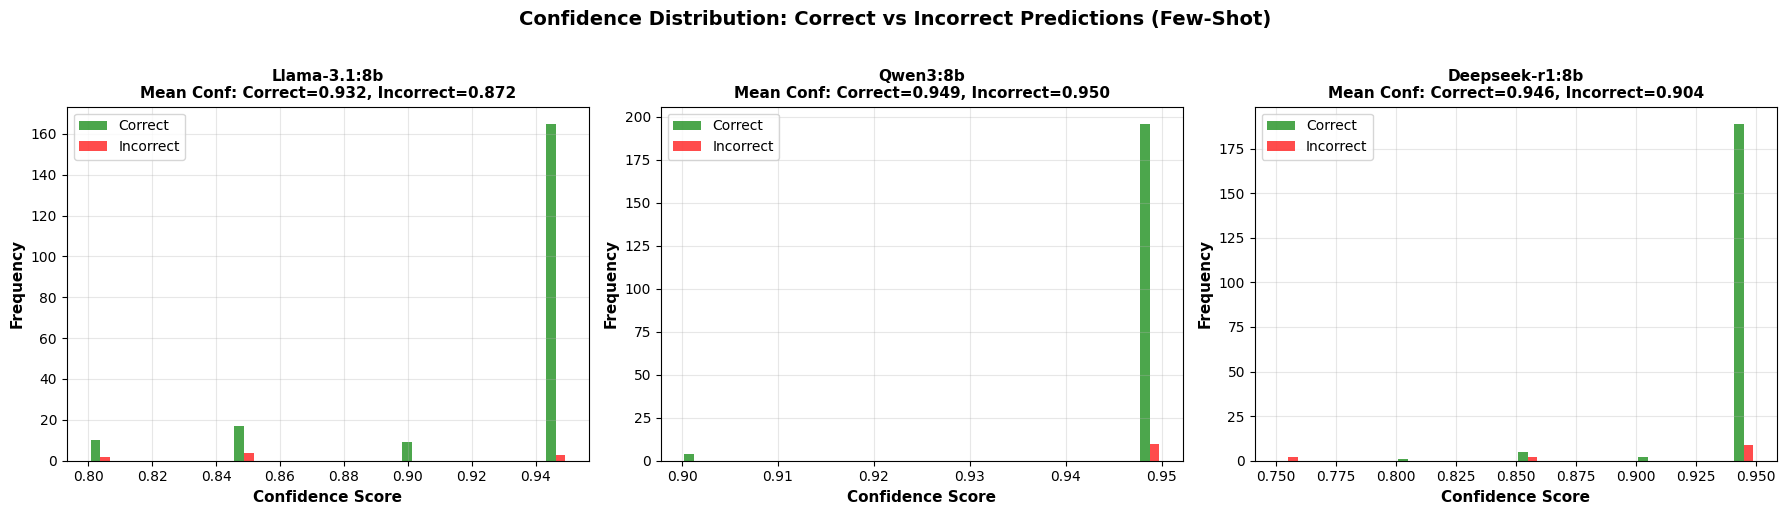


CONFIDENCE CALIBRATION ANALYSIS

E4: Llama3.1:8B:
  Average Confidence (Correct): 0.9318
  Average Confidence (Incorrect): 0.8722
  Calibration Gap: 0.0596
  Total Correct: 201 / 210

  Confidence by Predicted Class:
    Positive: 0.9185 (n=65)
    Negative: 0.9368 (n=76)
    Neutral: 0.9312 (n=69)

E5: Qwen3:8b:
  Average Confidence (Correct): 0.9490
  Average Confidence (Incorrect): 0.9500
  Calibration Gap: -0.0010
  Total Correct: 200 / 210

  Confidence by Predicted Class:
    Positive: 0.9477 (n=64)
    Negative: 0.9492 (n=66)
    Neutral: 0.9500 (n=80)

E6: Deepseek-r1:8b:
  Average Confidence (Correct): 0.9462
  Average Confidence (Incorrect): 0.9038
  Calibration Gap: 0.0423
  Total Correct: 197 / 210

  Confidence by Predicted Class:
    Positive: 0.9350 (n=70)
    Negative: 0.9500 (n=69)
    Neutral: 0.9458 (n=71)


In [23]:
# Confidence Analysis
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (df_result, title) in enumerate(
    [(e4_valid, "Llama-3.1:8b"), (e5_valid, "Qwen3:8b"), (e6_valid, "Deepseek-r1:8b")]
):
    df_result["correct"] = (
        df_result["true_sentiment"] == df_result["predicted_sentiment"]
    )

    correct_conf = df_result[df_result["correct"]]["confidence"]
    incorrect_conf = df_result[~df_result["correct"]]["confidence"]

    axes[idx].hist(
        [correct_conf, incorrect_conf],
        bins=20,
        label=["Correct", "Incorrect"],
        alpha=0.7,
        color=["green", "red"],
    )
    axes[idx].set_xlabel("Confidence Score", fontsize=11, weight="bold")
    axes[idx].set_ylabel("Frequency", fontsize=11, weight="bold")
    axes[idx].set_title(
        f"{title}\nMean Conf: Correct={correct_conf.mean():.3f}, Incorrect={incorrect_conf.mean():.3f}",
        fontsize=11,
        weight="bold",
    )
    axes[idx].legend()
    axes[idx].grid(alpha=0.3)

plt.suptitle(
    "Confidence Distribution: Correct vs Incorrect Predictions (Few-Shot)",
    fontsize=14,
    weight="bold",
    y=1.02,
)
plt.tight_layout()
plt.savefig("few_shot_confidence_analysis.png", dpi=300, bbox_inches="tight")
plt.show()

print("\n" + "=" * 80)
print("CONFIDENCE CALIBRATION ANALYSIS")
print("=" * 80)
for df_result, exp_name in [
    (e4_valid, "E4: Llama3.1:8B"),
    (e5_valid, "E5: Qwen3:8b"),
    (e6_valid, "E6: Deepseek-r1:8b"),
]:
    df_result["correct"] = (
        df_result["true_sentiment"] == df_result["predicted_sentiment"]
    )

    avg_conf_correct = df_result[df_result["correct"]]["confidence"].mean()
    avg_conf_incorrect = df_result[~df_result["correct"]]["confidence"].mean()
    calibration_gap = avg_conf_correct - avg_conf_incorrect

    print(f"\n{exp_name}:")
    print(f"  Average Confidence (Correct): {avg_conf_correct:.4f}")
    print(f"  Average Confidence (Incorrect): {avg_conf_incorrect:.4f}")
    print(f"  Calibration Gap: {calibration_gap:.4f}")
    print(f"  Total Correct: {df_result['correct'].sum()} / {len(df_result)}")

    # Confidence by sentiment class
    print(f"\n  Confidence by Predicted Class:")
    for sentiment in ["positive", "negative", "neutral"]:
        class_df = df_result[df_result["predicted_sentiment"] == sentiment]
        if len(class_df) > 0:
            print(
                f"    {sentiment.capitalize()}: {class_df['confidence'].mean():.4f} (n={len(class_df)})"
            )

## 11. Classification Reports

In [24]:
# Detailed Classification Reports
print("\n" + "=" * 80)
print("DETAILED CLASSIFICATION REPORTS")
print("=" * 80)

for df_result, exp_name in [
    (e4_valid, "E4: Llama-3.1-8B"),
    (e5_valid, "E5: Qwen3-8B"),
    (e6_valid, "E6: Deepseek-r1-8B"),
]:
    print("\n" + "=" * 80)
    print(f"{exp_name}")
    print("=" * 80)
    print(
        classification_report(
            df_result["true_sentiment"],
            df_result["predicted_sentiment"],
            labels=["positive", "negative", "neutral"],
            target_names=["Positive", "Negative", "Neutral"],
        )
    )

# Class-wise Metrics Summary Table
print("\n" + "=" * 80)
print("CLASS-WISE METRICS SUMMARY")
print("=" * 80)

summary_data = []
for metrics, model in [
    (e4_metrics, "Llama-3.1:8b"),
    (e5_metrics, "Qwen3..1:8b"),
    (e6_metrics, "deepseek-r1:8b"),
]:
    summary_data.append(
        {
            "Model": model,
            "Pos_P": metrics["Positive_Precision"],
            "Pos_R": metrics["Positive_Recall"],
            "Pos_F1": metrics["Positive_F1"],
            "Neg_P": metrics["Negative_Precision"],
            "Neg_R": metrics["Negative_Recall"],
            "Neg_F1": metrics["Negative_F1"],
            "Neu_P": metrics["Neutral_Precision"],
            "Neu_R": metrics["Neutral_Recall"],
            "Neu_F1": metrics["Neutral_F1"],
        }
    )

summary_df = pd.DataFrame(summary_data)
print("\nPer-Class Metrics (P=Precision, R=Recall, F1=F1-Score):")
display(summary_df.round(4))


DETAILED CLASSIFICATION REPORTS

E4: Llama-3.1-8B
              precision    recall  f1-score   support

    Positive       0.98      0.91      0.95        70
    Negative       0.92      1.00      0.96        70
     Neutral       0.97      0.96      0.96        70

    accuracy                           0.96       210
   macro avg       0.96      0.96      0.96       210
weighted avg       0.96      0.96      0.96       210


E5: Qwen3-8B
              precision    recall  f1-score   support

    Positive       1.00      0.91      0.96        70
    Negative       1.00      0.94      0.97        70
     Neutral       0.88      1.00      0.93        70

    accuracy                           0.95       210
   macro avg       0.96      0.95      0.95       210
weighted avg       0.96      0.95      0.95       210


E6: Deepseek-r1-8B
              precision    recall  f1-score   support

    Positive       0.91      0.91      0.91        70
    Negative       0.99      0.97      0.98 

,Model,Pos_P,Pos_R,Pos_F1,Neg_P,Neg_R,Neg_F1,Neu_P,Neu_R,Neu_F1
0,Llama-3.1:8b,0.9846,0.9143,0.9481,0.9211,1.0000,0.9589,0.9710,0.9571,0.9640
1,Qwen3..1:8b,1.0000,0.9143,0.9552,1.0000,0.9429,0.9706,0.8750,1.0000,0.9333
2,deepseek-r1:8b,0.9143,0.9143,0.9143,0.9855,0.9714,0.9784,0.9155,0.9286,0.9220


## 12. Few-Shot vs Zero-Shot Comparison

In [25]:
# Compare with Zero-Shot results (if available)
import glob
import os

print("=" * 80)
print("FEW-SHOT vs ZERO-SHOT COMPARISON")
print("=" * 80)

# Try to load the latest zero-shot results
zero_shot_files = glob.glob("../Zero_Shot/zero_shot_metrics_summary_*.csv")

if zero_shot_files:
    # Get the most recent file
    latest_zero_shot = max(zero_shot_files, key=os.path.getctime)
    print(f"\nLoading Zero-Shot results from: {os.path.basename(latest_zero_shot)}")

    try:
        zero_shot_df = pd.read_csv(latest_zero_shot)

        # Combine Few-Shot and Zero-Shot for comparison
        few_shot_df = metrics_df.copy()
        few_shot_df["Approach"] = "Few-Shot"
        zero_shot_df["Approach"] = "Zero-Shot"

        # Select key metrics for comparison
        comparison_cols = [
            "Experiment",
            "Approach",
            "Accuracy",
            "Macro-F1",
            "Negative_F1",
            "Positive_F1",
            "Neutral_F1",
        ]

        combined = pd.concat(
            [
                few_shot_df[comparison_cols]
                if all(col in few_shot_df.columns for col in comparison_cols)
                else few_shot_df,
                zero_shot_df[comparison_cols]
                if all(col in zero_shot_df.columns for col in comparison_cols)
                else zero_shot_df,
            ]
        )

        print("\nKey Metrics Comparison:")
        display(combined[comparison_cols].round(4))

        # Calculate improvements
        print("\n" + "=" * 80)
        print("IMPROVEMENT: Few-Shot vs Zero-Shot")
        print("=" * 80)

        model_names = ["Llama3.1:8b", "Qwen3:8b", "Deepseek-r1:8b"]
        for i in range(min(3, len(few_shot_df))):
            model_name = model_names[i]
            if i < len(zero_shot_df):
                fs_macro = few_shot_df.iloc[i]["Macro-F1"]
                zs_macro = zero_shot_df.iloc[i]["Macro-F1"]
                improvement = (
                    ((fs_macro - zs_macro) / zs_macro * 100) if zs_macro > 0 else 0
                )

                fs_neg = few_shot_df.iloc[i]["Negative_F1"]
                zs_neg = zero_shot_df.iloc[i]["Negative_F1"]
                neg_improvement = (
                    ((fs_neg - zs_neg) / zs_neg * 100)
                    if zs_neg > 0
                    else float("inf")
                    if fs_neg > 0
                    else 0
                )

                print(f"\n{model_name}:")
                print(
                    f"  Macro-F1: {zs_macro:.4f} → {fs_macro:.4f} ({improvement:+.2f}%)"
                )
                print(
                    f"  Negative F1: {zs_neg:.4f} → {fs_neg:.4f} ({neg_improvement:+.2f}% improvement)"
                    if neg_improvement != float("inf")
                    else f"  Negative F1: {zs_neg:.4f} → {fs_neg:.4f} (∞% - from zero!)"
                )

    except Exception as e:
        print(f"\n⚠️ Could not load zero-shot results: {str(e)}")
        print("Run Zero-Shot experiments first for comparison.")
else:
    print("\n⚠️ No Zero-Shot results found in ../Zero_Shot/")
    print("Run Zero-Shot experiments first to enable comparison.")

FEW-SHOT vs ZERO-SHOT COMPARISON

Loading Zero-Shot results from: zero_shot_metrics_summary_20260222_225323.csv

Key Metrics Comparison:


,Experiment,Approach,Accuracy,Macro-F1,Negative_F1,Positive_F1,Neutral_F1
0,E4: Llama-3.1:8b (Few-Shot),Few-Shot,0.9571,0.9570,0.9589,0.9481,0.9640
1,E5: Qwen3:8b (Few-Shot),Few-Shot,0.9524,0.9530,0.9706,0.9552,0.9333
2,E6: Deepseek-r1:8b (Few-Shot),Few-Shot,0.9381,0.9382,0.9784,0.9143,0.9220
0,E1: llama3.1:8b,Zero-Shot,0.9286,0.9278,0.9589,0.9167,0.9077
1,E2: qwen3:8b,Zero-Shot,0.9524,0.9527,0.9710,0.9565,0.9306
2,E3: deepseek-r1:8b,Zero-Shot,0.9667,0.9668,0.9710,0.9784,0.9510



IMPROVEMENT: Few-Shot vs Zero-Shot

Llama3.1:8b:
  Macro-F1: 0.9278 → 0.9570 (+3.16%)
  Negative F1: 0.9589 → 0.9589 (+0.00% improvement)

Qwen3:8b:
  Macro-F1: 0.9527 → 0.9530 (+0.04%)
  Negative F1: 0.9710 → 0.9706 (-0.04% improvement)

Deepseek-r1:8b:
  Macro-F1: 0.9668 → 0.9382 (-2.96%)
  Negative F1: 0.9710 → 0.9784 (+0.76% improvement)
